## 데이터 살펴보기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
submission_df = pd.read_csv('data/sampleSubmission.csv')

In [3]:
train_df.shape, test_df.shape, submission_df.shape

((10886, 12), (6493, 9), (6493, 2))

In [4]:
print('train_df.columns:\n', train_df.columns ,'\ntest_df.columns:\n', test_df.columns ,'\nsubmission_df.columns\n:', submission_df.columns)

train_df.columns:
 Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object') 
test_df.columns:
 Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='object') 
submission_df.columns
: Index(['datetime', 'count'], dtype='object')


In [5]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB


In [10]:
train_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [11]:
train_df.describe(include= 'object')

,datetime
count,10886
unique,10886
top,2011-01-01 00:00:00
freq,1


In [12]:
# datetime 변수 분해
train_df['datetime']=pd.to_datetime(train_df['datetime'])
train_df['year']=train_df['datetime'].dt.year
train_df['month']=train_df['datetime'].dt.month
train_df['day']=train_df['datetime'].dt.day
train_df['hour']=train_df['datetime'].dt.hour
train_df['minute']=train_df['datetime'].dt.minute
train_df['second']=train_df['datetime'].dt.second
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


In [13]:
print(train_df['minute'].value_counts())
print(train_df['second'].value_counts())

minute
0    10886
Name: count, dtype: int64
second
0    10886
Name: count, dtype: int64


In [14]:
train_df=train_df.drop(columns=['minute','second'], axis=1)
train_df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour'],
      dtype='object')

In [ ]:
test_df['datetime'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df['datetime'].dt.yearcd 
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour

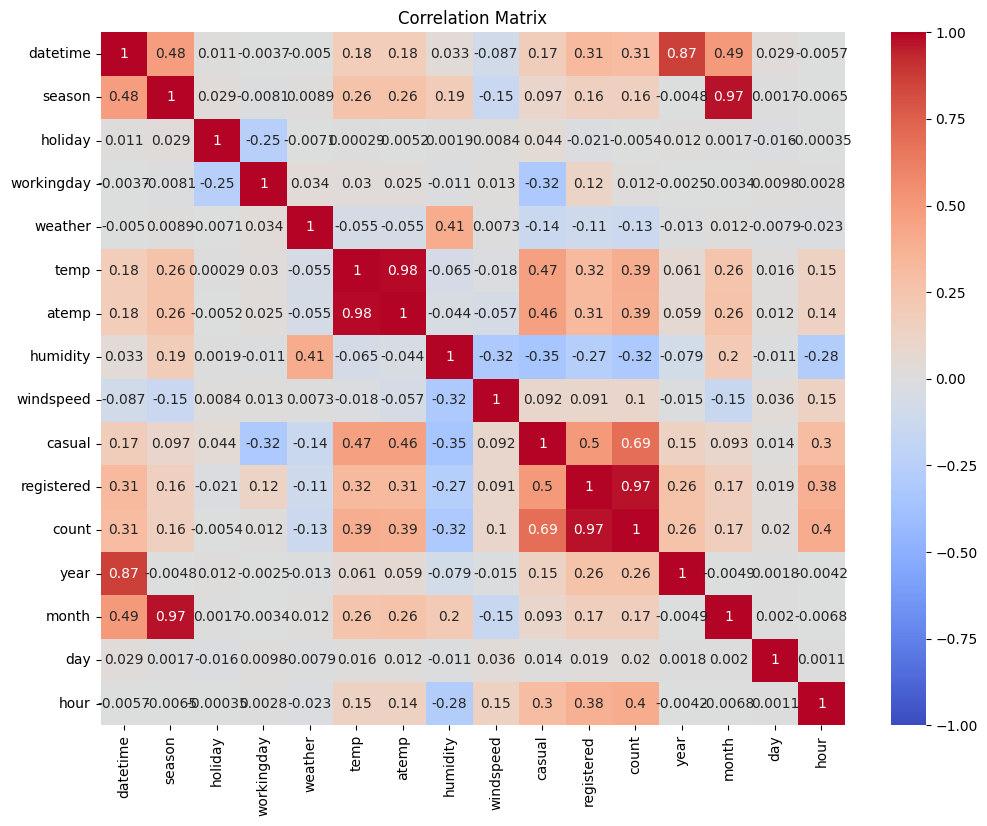

In [16]:
df=pd.DataFrame(train_df)

correlation_matrix=df.corr()

plt.figure(figsize=(12,9))
correlation_matrix=df.corr()
sns.heatmap(correlation_matrix, vmax=1, vmin=-1, center=0, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

우리가 구해야할 count 변수와 상관이 많은 특성으로는 진한 빨간색이나 파란색으로 표시되어 져 있는 temp, atemp, humidity, hour등이 눈에 띈다.

## 답안지 파일 살펴보기

In [17]:
submission_df.shape

(6493, 2)

In [18]:
submission_df.head()

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0


## 모델 학습 및 답안 제출

In [19]:
X=train_df.drop(columns=['count'])
y=train_df['count']

In [20]:
X=train_df.drop(columns=['count','casual','registered','datetime'])
y=train_df['count']

In [21]:
X_test = test_df.drop(columns=['datetime'])

In [22]:
print(f'Train data shape: {X.shape}')
print(f'Number of null values: {X.isna().sum().sum()}')
print(f'\nTest data shape: {X_test.shape}')
print(f'Number of null values: {X_test.isna().sum().sum()}')

Train data shape: (10886, 12)
Number of null values: 0

Test data shape: (6493, 12)
Number of null values: 0


In [23]:
X.columns, X_test.columns

(Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour'],
       dtype='object'),
 Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour'],
       dtype='object'))

In [24]:
def separate_train(df):
    X = df.drop(columns=['count','casual','registered','datetime'],axis=1)
    y = df['count']
    return X, y

def separate_test(df):
    X_test = df.drop('datetime',axis=1)
    return X_test

In [25]:
X,y= separate_train(train_df)
X_test= separate_test(test_df)

print(f'Train data shape: {X.shape}')
print(f'Number of null values: {X.isna().sum().sum()}')
print(f'\nTest data shape: {X_test.shape}')
print(f'Number of null values: {X_test.isna().sum().sum()}')

Train data shape: (10886, 12)
Number of null values: 0

Test data shape: (6493, 12)
Number of null values: 0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid= train_test_split(X,y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_valid_pred=model.predict(X_valid)

In [29]:
y_valid_pred=np.maximum(0, y_valid_pred)

In [30]:
from sklearn.metrics import mean_squared_log_error

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'\nValidation RMSLE: {rmsle:.5f}')


Validation RMSLE: 1.30575


In [31]:
y_test_pred=model.predict(X_test)
y_test_pred=np.maximum(0, y_test_pred)

In [32]:
submission_df['count']=y_test_pred
submission_df.to_csv('submission_baseline.csv', index=False)
submission_df

,datetime,count
0,2011-01-20 00:00:00,0.000000
1,2011-01-20 01:00:00,0.000000
2,2011-01-20 02:00:00,0.000000
3,2011-01-20 03:00:00,0.000000
4,2011-01-20 04:00:00,0.000000
...,...,...
6488,2012-12-31 19:00:00,299.166115
6489,2012-12-31 20:00:00,307.029709
6490,2012-12-31 21:00:00,320.079545
6491,2012-12-31 22:00:00,338.774422


## 피쳐 엔지니어링(Feature Engineering)

- 피쳐 엔지니어링이란, 머신러닝 모델의 성능을 향상시키기 위해 원본 데이터의 변수를 가공하는 과정을 의미한다. 이때 결측값이나 이상점을 처리하기도 하고, 새로운 피쳐를 생성하거나 기존의 변수들을 결합하여 더 의미 있는 정보를 추출하기도 한다. 피쳐 엔지니어링은 모델의 성능에 큰 영향을 미치는 아주 중요한 작업이다.

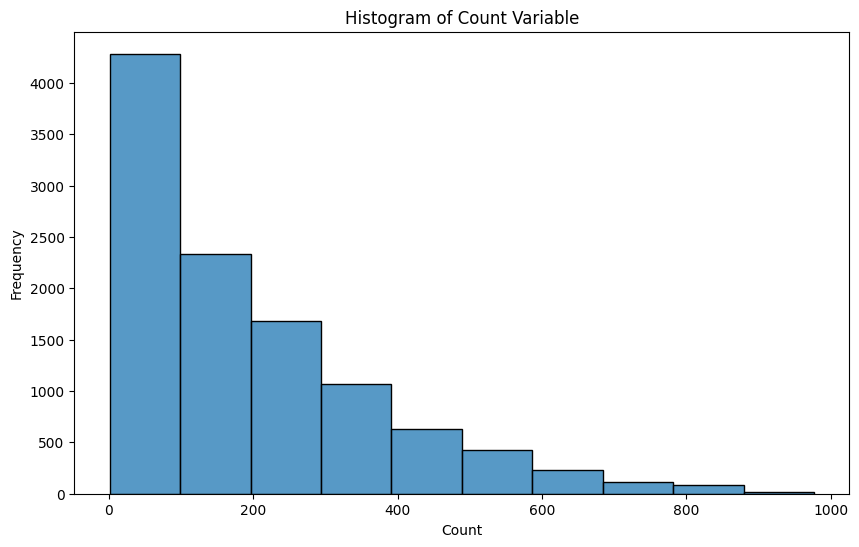

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(data=train_df, x='count', bins=10)
plt.title('Histogram of Count Variable')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

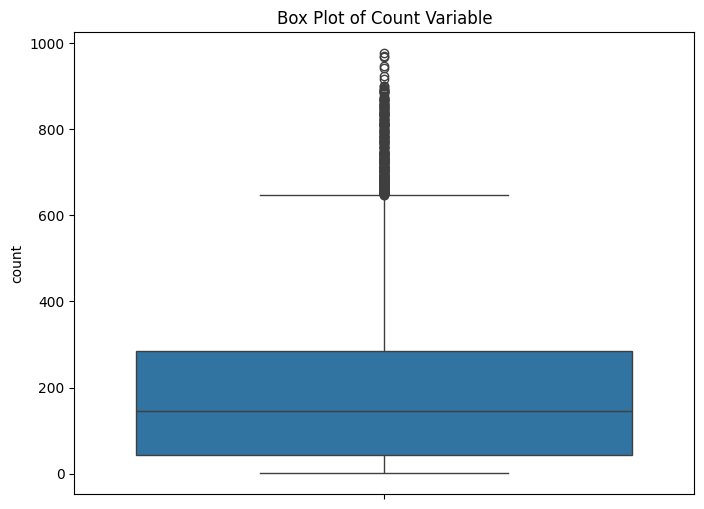

In [34]:
plt.figure(figsize=(8,6))
sns.boxplot(data=train_df, y='count')
plt.title('Box Plot of Count Variable')
plt.ylabel('count')
plt.show()

In [35]:
train_df['count'].min()

np.int64(1)

count의 최솟값은 1이다. 데이터를 자세히 살펴보면 자전거 대여가 없는 시간대에는 count값이 0으로 되어 있는것이 아니라, 아예 그 시간대에 해당하는 행이 존재하지 않는다는 것을 알 수 있다.

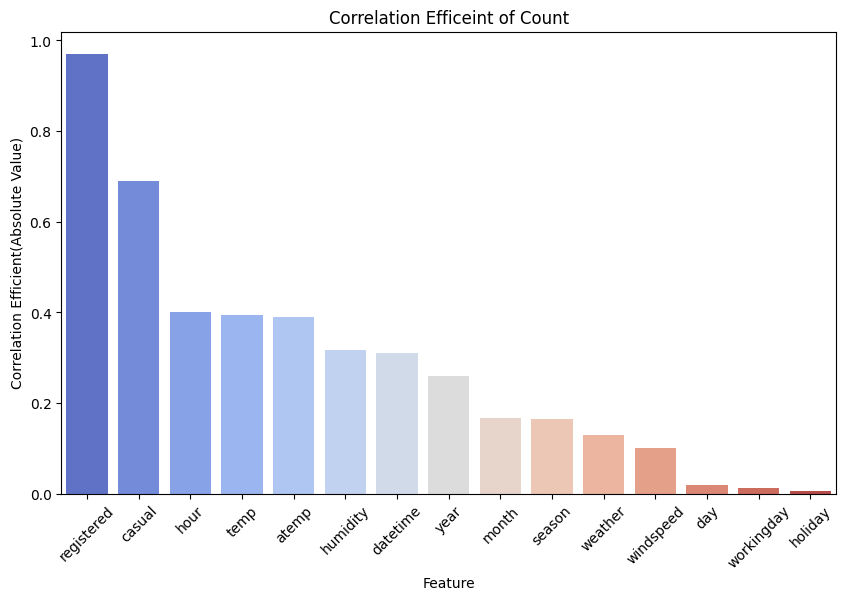

In [36]:
corr_df=correlation_matrix['count'].abs().sort_values(ascending=False).drop('count')

plt.figure(figsize=(10,6))
sns.barplot(data=corr_df.reset_index(), x='index', y='count', hue='index', palette='coolwarm', legend=False)
plt.xlabel('Feature')
plt.ylabel('Correlation Efficient(Absolute Value)')
plt.title('Correlation Efficeint of Count')
plt.xticks(rotation=45)
plt.show()

In [37]:
for col in ['year', 'month', 'day', 'hour']:
    unique_values = train_df[col].unique()
    unique_values.sort()
    print(col)
    print(unique_values)

year
[2011 2012]
month
[ 1  2  3  4  5  6  7  8  9 10 11 12]
day
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
hour
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [38]:
for col in ['year', 'month', 'day', 'hour'] :
    unique_values = sorted(test_df[col].unique())
    print(col)
    print(unique_values)


year
[np.int32(2011), np.int32(2012)]
month
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
day
[np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]
hour
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


## 기간별 자전거 대여량 시각화

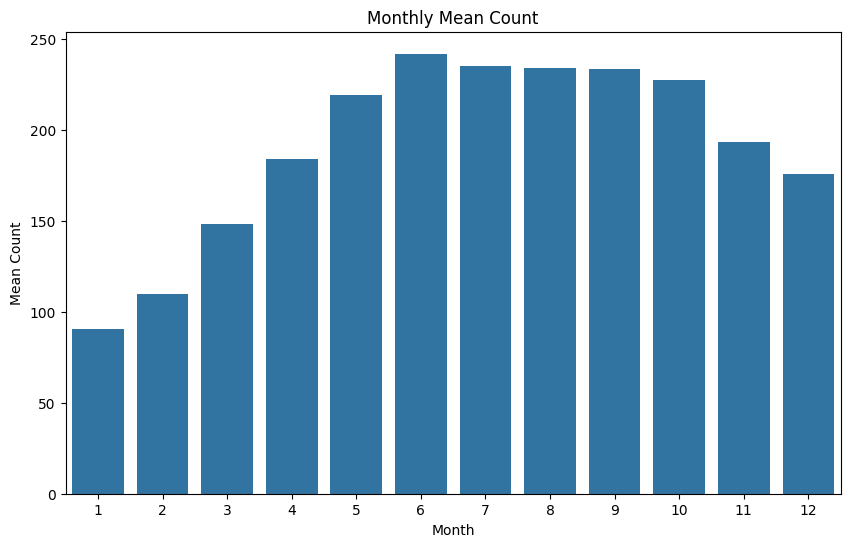

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='month', y='count', errorbar=None)
plt.title('Monthly Mean Count')
plt.xlabel('Month')
plt.ylabel('Mean Count')
plt.show()

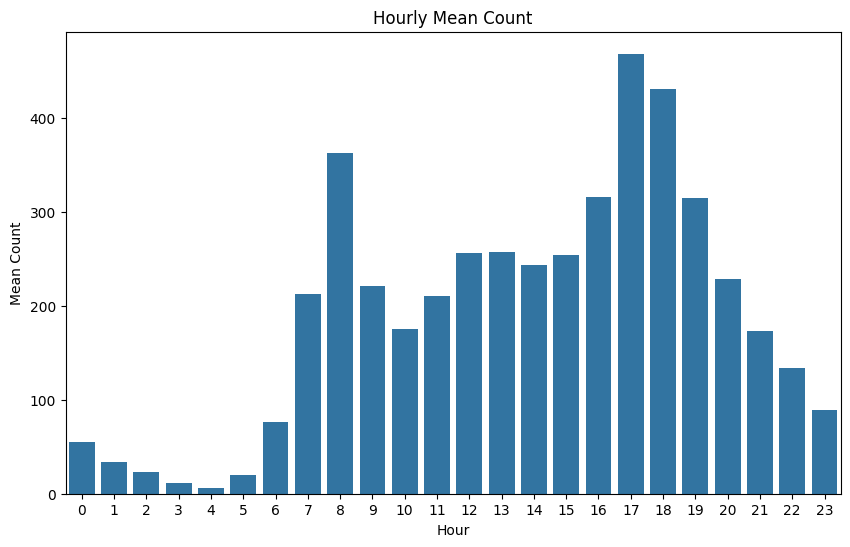

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='hour', y='count', errorbar=None)
plt.title('Hourly Mean Count')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.show()

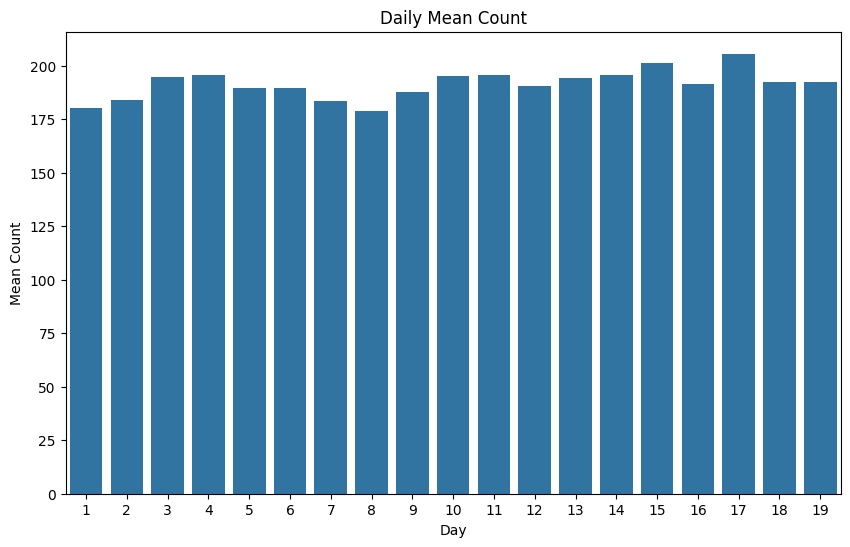

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='day', y='count', errorbar=None)
plt.title('Daily Mean Count')
plt.xlabel('Day')
plt.ylabel('Mean Count')
plt.show()

날짜와 대여량 사이에는 유의미한 차이(인사이트)가 존재하지 않는 것으로 보인다.

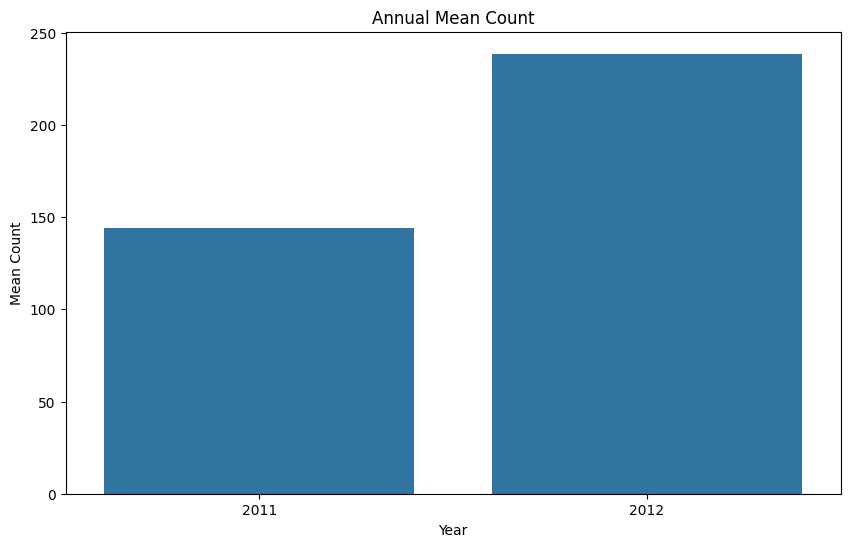

In [42]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='year', y='count', errorbar=None)
plt.title('Annual Mean Count')
plt.xlabel('Year')
plt.ylabel('Mean Count')
plt.show()

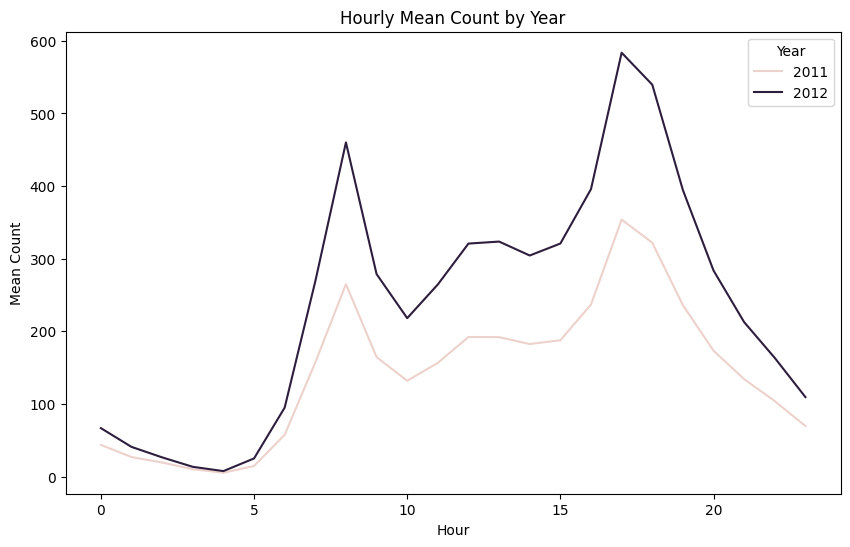

In [43]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='hour', y='count', hue='year', errorbar=None)
plt.title('Hourly Mean Count by Year')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Year')
plt.show()

## 계절별 자전거 대여량 시각화

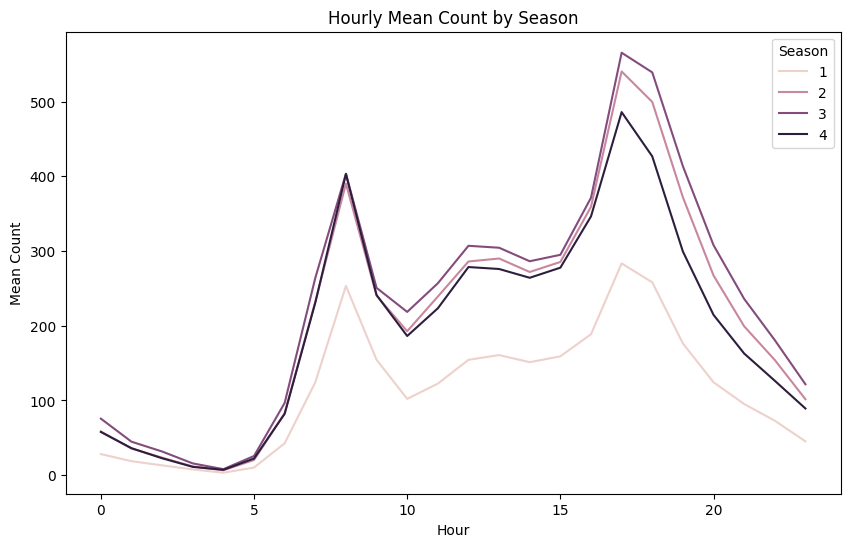

In [44]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='hour', y='count', hue='season', errorbar=None)
plt.title('Hourly Mean Count by Season')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Season')
plt.show()

Season 변수는 1부터 4까지 4개의 값으로 이루어져있기 때문에 4개의 라인 차트를 확인할 수 있고, 전체적인 그래프의 모양은 모두 비슷하게 생겼다. 그런데 season이 1일때에는 출퇴근 시간대에도 대여량의 증가폭이 작은편이다.

## 날씨별 자전거 대여량 시각화

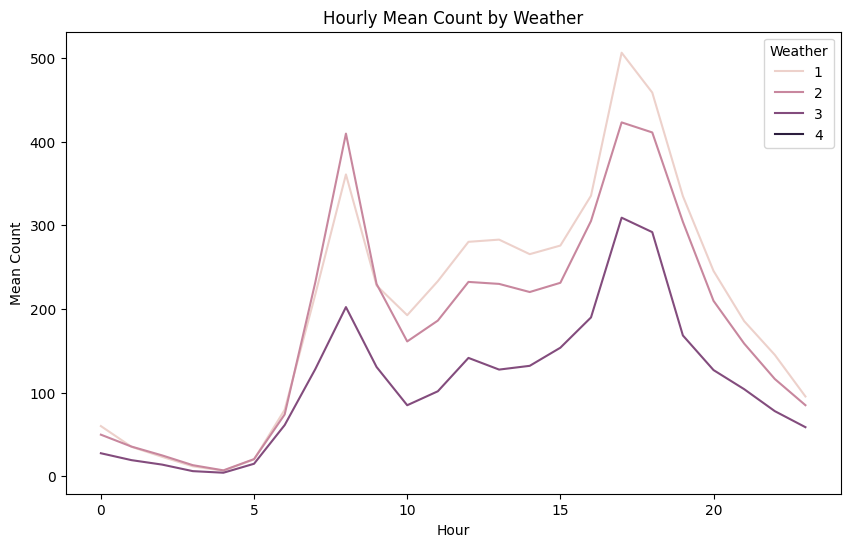

In [45]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='hour', y='count', hue='weather', errorbar=None)
plt.title('Hourly Mean Count by Weather')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Weather')
plt.show()

In [46]:
train_df['weather'].value_counts()


weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

그래프의 범례(legend)를 보면 그래프가 4개가 보여야 하는데, 3개 밖에 안보이는데, 이유는 weather가 4인 데이터는 딱 하나밖에 없기 때문이다.

## temp와 atemp 살펴보기

In [47]:
train_df['temp'].unique() 

array([ 9.84,  9.02,  8.2 , 13.12, 15.58, 14.76, 17.22, 18.86, 18.04,
       16.4 , 13.94, 12.3 , 10.66,  6.56,  5.74,  7.38,  4.92, 11.48,
        4.1 ,  3.28,  2.46, 21.32, 22.96, 23.78, 24.6 , 19.68, 22.14,
       20.5 , 27.06, 26.24, 25.42, 27.88, 28.7 , 30.34, 31.16, 29.52,
       33.62, 35.26, 36.9 , 32.8 , 31.98, 34.44, 36.08, 37.72, 38.54,
        1.64,  0.82, 39.36, 41.  ])

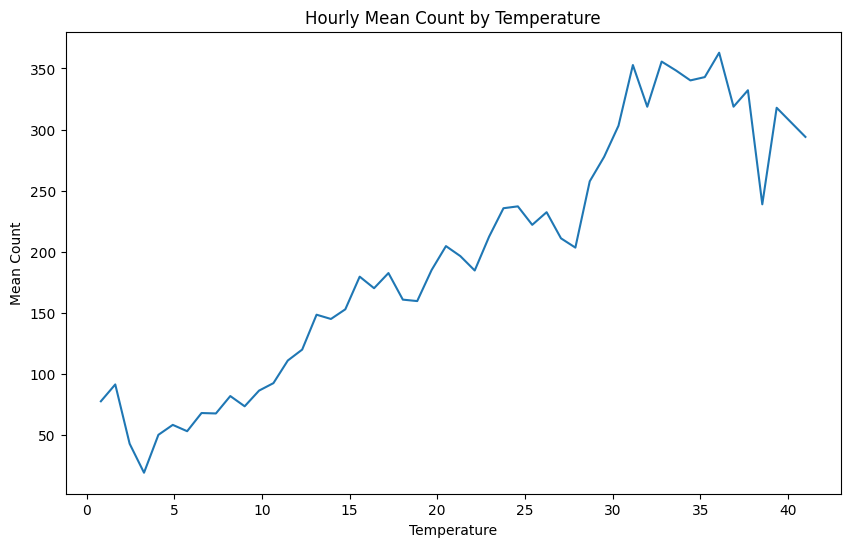

In [48]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='temp', y='count', errorbar=None)
plt.title('Hourly Mean Count by Temperature')
plt.xlabel('Temperature')
plt.ylabel('Mean Count')
plt.show()

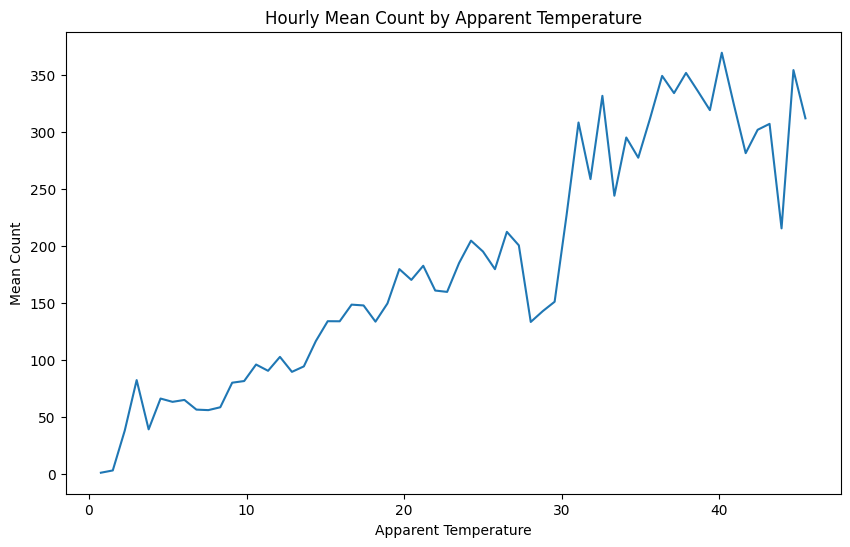

In [49]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='atemp', y='count', errorbar=None)
plt.title('Hourly Mean Count by Apparent Temperature')
plt.xlabel('Apparent Temperature')
plt.ylabel('Mean Count')
plt.show()


온도, 체감온도는 비슷한 양상을 보여주는데, 증가할수록 자전거 대여량도 같이 증가하는 경향을 보인다.

## day_of_week 변수 추가하기

In [50]:
train_df['day_of_week'] = train_df['datetime'].dt.dayofweek
test_df['day_of_week'] = test_df['datetime'].dt.dayofweek

# day_of_week 변수 추가함으로써 무슨 요일인지 숫자로 나타내서 월요일부터 일요일까지를 각각 0~6 숫자에 대응시켜 나타낸다.

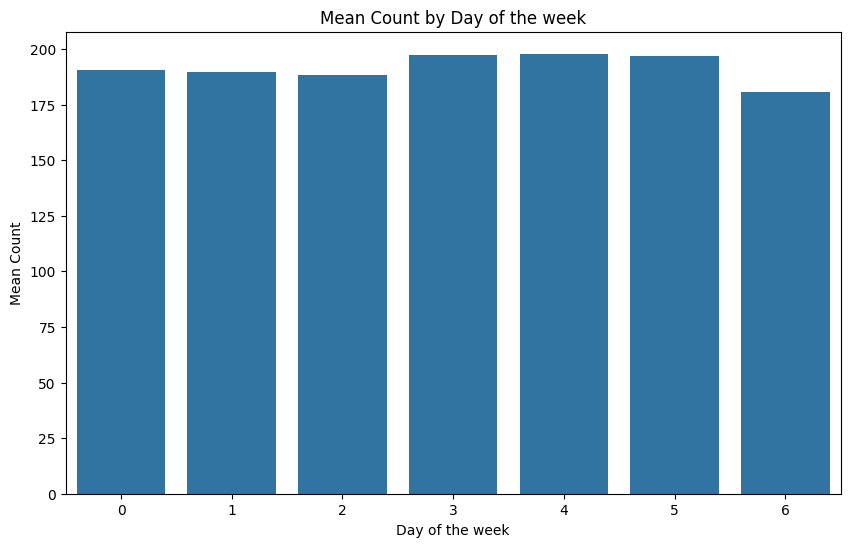

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='day_of_week', y='count', errorbar=None)
plt.title('Mean Count by Day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Mean Count')
plt.show()

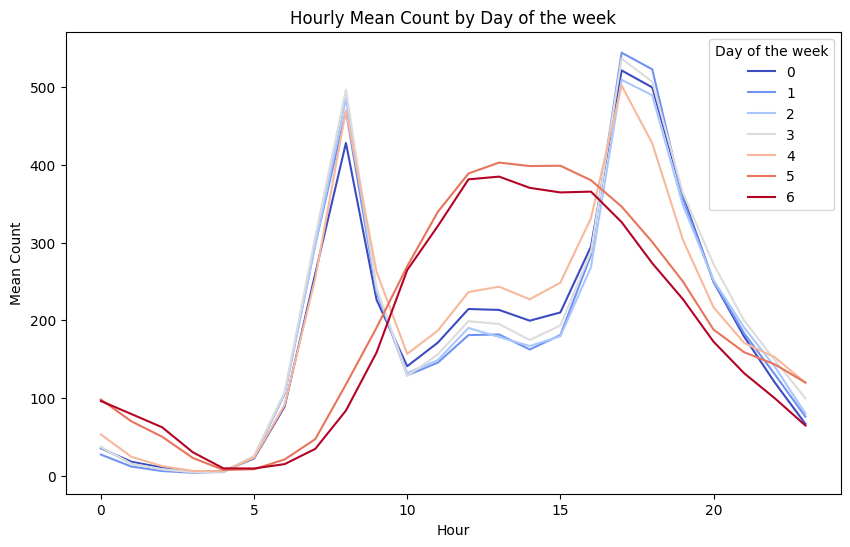

In [52]:
plt.figure(figsize=(10,6))
sns.lineplot(data=train_df, x='hour', y='count', hue='day_of_week', errorbar=None, palette='coolwarm')
plt.title('Hourly Mean Count by Day of the week')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Day of the week')
plt.show()

월요일 부터 금요일에 해당하는 0~4의 경우, 아침 6시부터 급격하게 증가해서 대략 9시쯤 가장 높은 대여량을 보이다가 이후로 감소하다가 15시부터 서서히 증가하여 17~18시 쯤 가장 높은 값을 보이지만, 반면 5~6에 해당하는 토여일붜 일요일은 10~15시 사이 가장 높은 대여량을 보여준다.

## Count 변수 로그 변환하기
- 로그 변환은 어떤 변수에 로그를 취하는 작업을 의미하는데, Count 변수처럼 오른쪽으로 치우쳐진 불균형한 데이터가 있을때, 로그 변환을 통해 좀 더 정규 분포와 비슷한 형태로 만들어주는 효과가 있다.

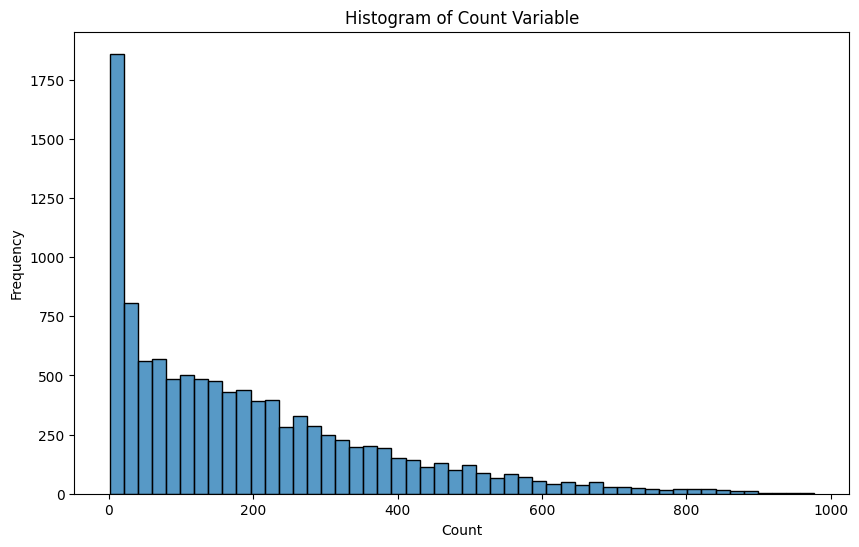

In [53]:
plt.figure(figsize=(10,6))
sns.histplot(train_df['count'], bins=50)
plt.title('Histogram of Count Variable')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

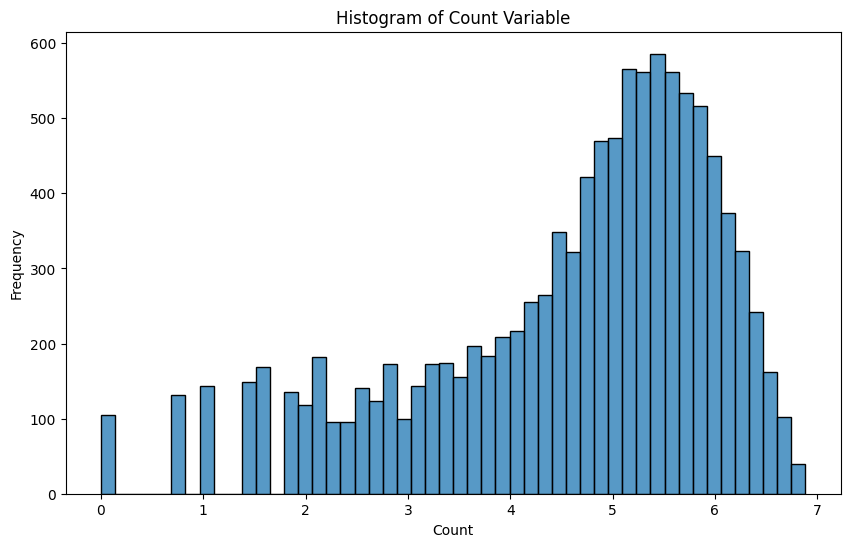

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log(train_df['count']), bins=50)
plt.title('Histogram of Count Variable')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

## 모델 학습 및 답안 제출

In [55]:
model = LinearRegression()
model.fit(X_train, np.log(y_train))

y_valid_pred = model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred))

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'\nValidation Data RMSLE: {rmsle:.5f}')

y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))


Validation Data RMSLE: 1.02697


In [56]:
submission_df['count'] = y_test_pred
submission_df.to_csv('submission_1.csv', index=False)

## RamdomForest 모델 사용하기

In [57]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)

In [58]:
X, y= separate_train(train_df)
X_test= separate_test(test_df)

X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2, random_state=42)

model.fit(X_train,np.log1p(y_train))

y_valid_pred=model.predict(X_valid)
y_valid_pred=np.maximum(1,np.expm1(y_valid_pred))

In [59]:
rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'Validation Data RMSLE: {rmsle:.5f}')

Validation Data RMSLE: 0.30474


In [60]:
y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))

submission_df['count'] = y_test_pred
submission_df.to_csv('submission_2-1.csv', index=False)

## humidity 변수 전처리

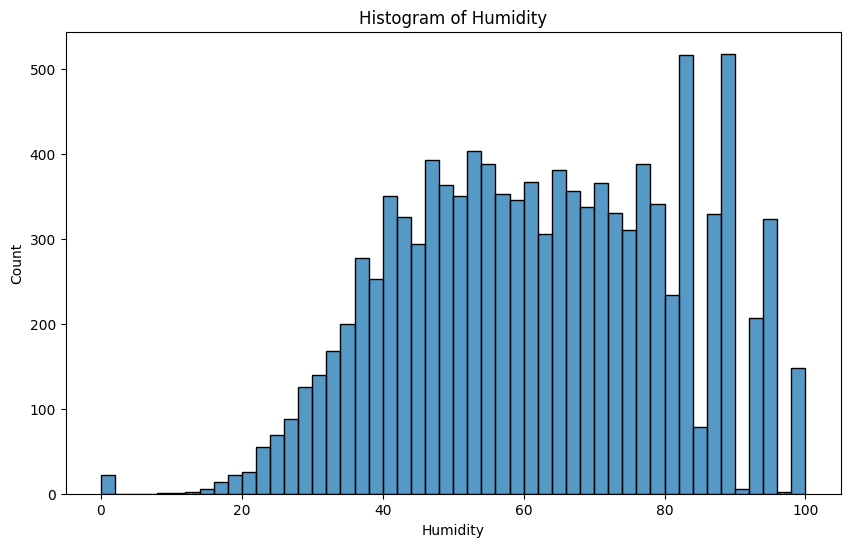

In [61]:
plt.figure(figsize=(10,6))
sns.histplot(train_df['humidity'], bins=50)
plt.title('Histogram of Humidity')
plt.xlabel('Humidity')
plt.ylabel('Count')
plt.show()

In [62]:
train_df['humidity'].min()

np.int64(0)

In [63]:
train_df[train_df['humidity'] == 0]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,day_of_week
1091,2011-03-10 00:00:00,1,0,1,3,13.94,15.910,0,16.9979,3,0,3,2011,3,10,0,3
1092,2011-03-10 01:00:00,1,0,1,3,13.94,15.910,0,16.9979,0,2,2,2011,3,10,1,3
1093,2011-03-10 02:00:00,1,0,1,3,13.94,15.910,0,16.9979,0,1,1,2011,3,10,2,3
1094,2011-03-10 05:00:00,1,0,1,3,14.76,17.425,0,12.9980,1,2,3,2011,3,10,5,3
1095,2011-03-10 06:00:00,1,0,1,3,14.76,16.665,0,22.0028,0,12,12,2011,3,10,6,3
1096,2011-03-10 07:00:00,1,0,1,3,15.58,19.695,0,15.0013,1,36,37,2011,3,10,7,3
1097,2011-03-10 08:00:00,1,0,1,3,15.58,19.695,0,19.0012,1,43,44,2011,3,10,8,3
1098,2011-03-10 09:00:00,1,0,1,3,16.40,20.455,0,15.0013,1,23,24,2011,3,10,9,3
1099,2011-03-10 10:00:00,1,0,1,3,16.40,20.455,0,11.0014,0,17,17,2011,3,10,10,3
1100,2011-03-10 11:00:00,1,0,1,3,16.40,20.455,0,16.9979,6,5,11,2011,3,10,11,3


In [64]:
avg_humidity = train_df.humidity.mean()
train_df.loc[train_df['humidity'] == 0, 'humidity'] = avg_humidity

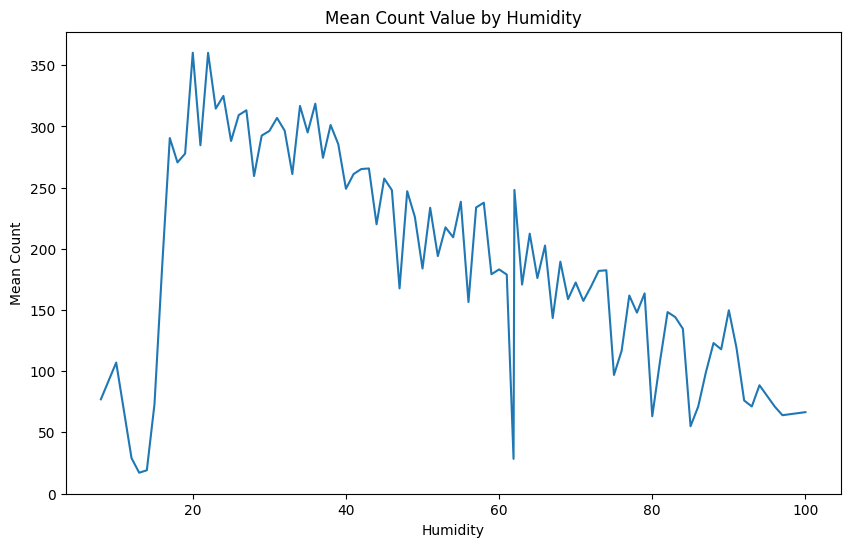

In [65]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='humidity', y='count', errorbar=None)
plt.title('Mean Count Value by Humidity')
plt.xlabel('Humidity')
plt.ylabel('Mean Count')
plt.show()


In [66]:
X, y = separate_train(train_df)
X_test = separate_test(test_df)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 초기화 및 학습
model = RandomForestRegressor(random_state=42)
model.fit(X_train, np.log1p(y_train))

# 검증 데이터에 대한 예측
y_valid_pred = model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred))

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'Validation Data RMSLE: {rmsle:.5f}')


Validation Data RMSLE: 0.30472


In [67]:
y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))

submission_df['count'] = y_test_pred
submission_df.to_csv('submission_2-2.csv', index=False)


## holiday 변수 살펴보기

In [68]:
train_df['holiday'].value_counts()

holiday
0    10575
1      311
Name: count, dtype: int64

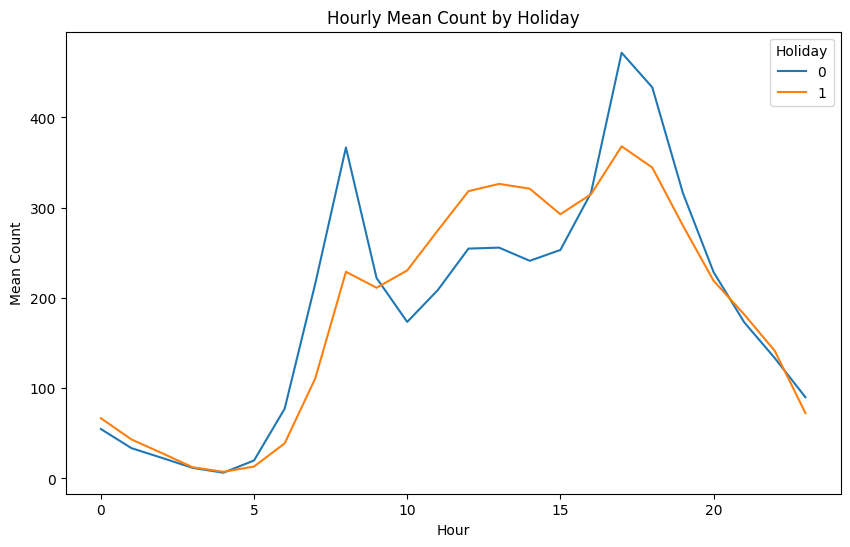

In [69]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='hour', y='count', hue='holiday', errorbar=None)
plt.title('Hourly Mean Count by Holiday')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Holiday')
plt.show()


## Workingday 변수 살펴보기

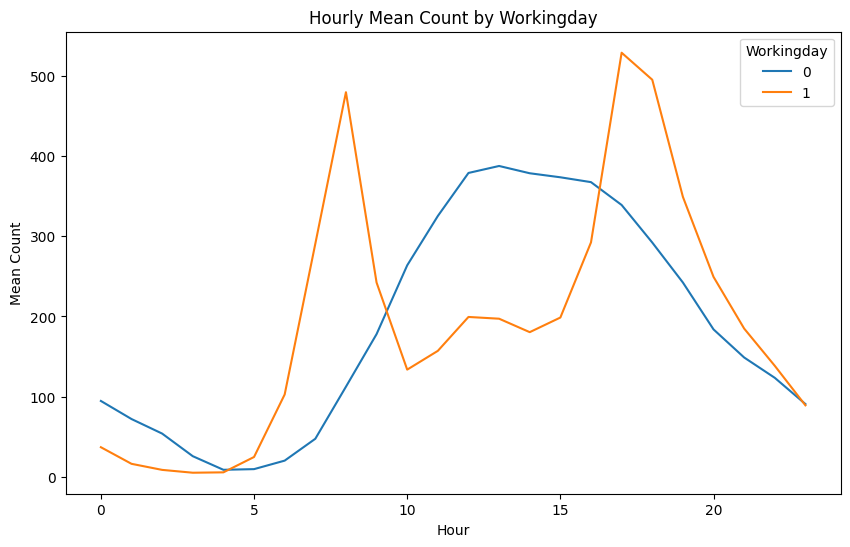

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='hour', y='count', hue='workingday', errorbar = None)
plt.title('Hourly Mean Count by Workingday')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Workingday')
plt.show()

In [71]:
train_df['daytype'] = 0
train_df.loc[train_df['day_of_week'] == 4, 'daytype'] = 1  # 금요일
train_df.loc[train_df['workingday'] == 0, 'daytype'] = 2 # 비영업일

test_df['daytype'] = 0
test_df.loc[test_df['day_of_week'] == 4, 'daytype'] = 1  # 금요일
test_df.loc[test_df['workingday'] == 0, 'daytype'] = 2 # 비영업일


Workingday와 day_of_week를 엮어서 살펴보면 day_of_week가 0~4인 것 중에서도, 4에 해당하는 그래프는 차이가 있어서, 일단 모든 행에 대해 0으로 채워 주고 특정 조건에서 1 혹은 2를 채워 주는 방식을 사용한다. 금요일, 즉 day_of_week 값이 4인 경우 1을 채워 넣었다. 그리고 workingday 값이 0인 경우(영업일이 아닌 경우)에는 2를 채워 넣었다. 여기서 주의할 점은, 어떤 날은 금요일인 동시에 공휴일일 수도 있다는 건데, 이럴 때에는 2라는 값이 들어가도록 코드 순서를 아래와 같이 작성해 줘야 한다.

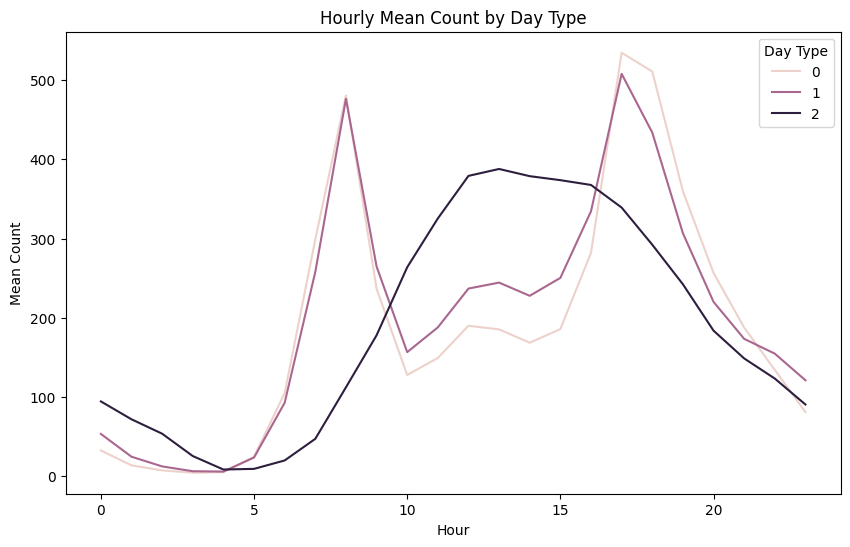

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='hour', y='count', hue='daytype', errorbar=None)
plt.title('Hourly Mean Count by Day Type')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Day Type')
plt.show()

In [73]:
train_df = train_df.drop(columns='workingday')
test_df = test_df.drop(columns='workingday')


## 모델 학습 및 답안 제출

In [74]:
X, y = separate_train(train_df)
X_test = separate_test(test_df)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 초기화 및 학습
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, np.log1p(y_train))

# 검증 데이터에 대한 예측
y_valid_pred = model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred))

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'Validation Data RMSLE: {rmsle:.5f}')

Validation Data RMSLE: 0.30277


In [75]:
y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))

submission_df['count'] = y_test_pred
submission_df.to_csv('submission_3.csv', index=False)


____

## 평균값 파생 피쳐와 변수 선택

#### 평균값 파생피쳐(hour) 추가하기

In [76]:
groupby_df = train_df.groupby('hour')['count'].mean().reset_index()
groupby_df.columns = ['hour', 'mean_count_by_hour']
groupby_df.head()

,hour,mean_count_by_hour
0,0,55.138462
1,1,33.859031
2,2,22.899554
3,3,11.757506
4,4,6.407240


In [77]:
train_df = train_df.merge(groupby_df, on='hour', how='left')
test_df = test_df.merge(groupby_df, on='hour', how='left')

In [78]:
train_df.head()

,datetime,season,holiday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,day_of_week,daytype,mean_count_by_hour
0,2011-01-01 00:00:00,1,0,1,9.84,14.395,81.0,0.0,3,13,16,2011,1,1,0,5,2,55.138462
1,2011-01-01 01:00:00,1,0,1,9.02,13.635,80.0,0.0,8,32,40,2011,1,1,1,5,2,33.859031
2,2011-01-01 02:00:00,1,0,1,9.02,13.635,80.0,0.0,5,27,32,2011,1,1,2,5,2,22.899554
3,2011-01-01 03:00:00,1,0,1,9.84,14.395,75.0,0.0,3,10,13,2011,1,1,3,5,2,11.757506
4,2011-01-01 04:00:00,1,0,1,9.84,14.395,75.0,0.0,0,1,1,2011,1,1,4,5,2,6.407240


#### 평균값 파생피쳐(daytype, hour) 추가하기

In [79]:
groupby_df = train_df.groupby(['daytype', 'hour'])['count'].mean().reset_index()
groupby_df.columns = ['daytype', 'hour', 'mc_daytype_hour']


In [80]:
train_df = train_df.merge(groupby_df, on=['daytype', 'hour'], how='left')
test_df = test_df.merge(groupby_df, on=['daytype', 'hour'], how='left')

In [81]:
train_df.head()

,datetime,season,holiday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,day_of_week,daytype,mean_count_by_hour,mc_daytype_hour
0,2011-01-01 00:00:00,1,0,1,9.84,14.395,81.0,0.0,3,13,16,2011,1,1,0,5,2,55.138462,94.489655
1,2011-01-01 01:00:00,1,0,1,9.02,13.635,80.0,0.0,8,32,40,2011,1,1,1,5,2,33.859031,71.910345
2,2011-01-01 02:00:00,1,0,1,9.02,13.635,80.0,0.0,5,27,32,2011,1,1,2,5,2,22.899554,53.748252
3,2011-01-01 03:00:00,1,0,1,9.84,14.395,75.0,0.0,3,10,13,2011,1,1,3,5,2,11.757506,25.534722
4,2011-01-01 04:00:00,1,0,1,9.84,14.395,75.0,0.0,0,1,1,2011,1,1,4,5,2,6.407240,8.544828


In [82]:
X, y = separate_train(train_df)
X_test = separate_test(test_df)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 초기화 및 학습
model = RandomForestRegressor(random_state=42)
model.fit(X_train, np.log1p(y_train))

# 검증 데이터에 대한 예측
y_valid_pred = model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred))

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'Validation Data RMSLE: {rmsle:.5f}')


Validation Data RMSLE: 0.30296


In [83]:
y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))

submission_df['count'] = y_test_pred
submission_df.to_csv('submission_4-1.csv', index=False)


In [84]:
drop_features = ['day', 'month', 'atemp']

train_df = train_df.drop(drop_features, axis=1)
test_df = test_df.drop(drop_features, axis=1)

## 모델 학습 및 답안 제출

In [85]:
X, y = separate_train(train_df)
X_test = separate_test(test_df)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 초기화 및 학습
model = RandomForestRegressor(random_state=42)
model.fit(X_train, np.log1p(y_train))

# 검증 데이터에 대한 예측
y_valid_pred = model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred))

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'Validation Data RMSLE: {rmsle:.5f}')


Validation Data RMSLE: 0.31257


In [86]:
y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))

submission_df['count'] = y_test_pred
submission_df.to_csv('submission_4-2.csv', index=False)


## 하이퍼파라미터 튜닝

In [87]:
from sklearn.model_selection import GridSearchCV

X, y = separate_train(train_df)
X_test = separate_test(test_df)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 하이퍼 파라미터 초기 설정
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [4, 6, 8],
}


In [88]:
model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, np.log1p(y_train))


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [4, 6, 8],
                         'n_estimators': [50, 100, 200]})

In [89]:
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_split': 6, 'n_estimators': 200}


In [90]:
best_model = grid_search.best_estimator_


In [91]:
y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred))

y_test_pred = best_model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))
rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'Validation Data RMSLE: {rmsle:.5f}')


Validation Data RMSLE: 0.30863


In [92]:
submission_df['count'] = y_test_pred
submission_df.to_csv('submission_5.csv', index=False)

----------------------------------------------------------------------

# Mine

## RMSLE 성능 개선 시도

지금까지 학습한 내용을 바탕으로 추가 성능 개선 방법들을 시도해보겠습니다:

1. **추가 피쳐 엔지니어링**: 시간대 그룹화, 계절-날씨 조합 피쳐
2. **다른 앙상블 모델**: Gradient Boosting (XGBoost, LightGBM)
3. **더 정교한 하이퍼파라미터 튜닝**
4. **앙상블 기법**: 여러 모델의 예측값 평균

In [ ]:
# 1. 추가 피쳐 엔지니어링
# 데이터 재로드 (기존 변환 다시 적용)
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# datetime 파싱
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

# 기본 시간 피쳐
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['day_of_week'] = train_df['datetime'].dt.dayofweek

test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['day_of_week'] = test_df['datetime'].dt.dayofweek

# humidity 전처리
avg_humidity = train_df['humidity'].mean()
train_df.loc[train_df['humidity'] == 0, 'humidity'] = avg_humidity

# daytype 피쳐
train_df['daytype'] = 0
train_df.loc[train_df['day_of_week'] == 4, 'daytype'] = 1
train_df.loc[train_df['workingday'] == 0, 'daytype'] = 2

test_df['daytype'] = 0
test_df.loc[test_df['day_of_week'] == 4, 'daytype'] = 1
test_df.loc[test_df['workingday'] == 0, 'daytype'] = 2

# 새로운 피쳐 1: 시간대 그룹 (출근, 점심, 퇴근, 밤)
def categorize_hour(hour):
    if 6 <= hour <= 9:
        return 1  # 출근시간
    elif 10 <= hour <= 15:
        return 2  # 낮시간
    elif 16 <= hour <= 19:
        return 3  # 퇴근시간
    else:
        return 4  # 밤/새벽

train_df['hour_group'] = train_df['hour'].apply(categorize_hour)
test_df['hour_group'] = test_df['hour'].apply(categorize_hour)

# 새로운 피쳐 2: 계절-날씨 조합
train_df['season_weather'] = train_df['season'].astype(str) + '_' + train_df['weather'].astype(str)
test_df['season_weather'] = test_df['season'].astype(str) + '_' + test_df['weather'].astype(str)

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_df['season_weather_encoded'] = le.fit_transform(train_df['season_weather'])
test_df['season_weather_encoded'] = le.transform(test_df['season_weather'])

# 새로운 피쳐 3: 온도 구간 (정수형으로 변환)
train_df['temp_group'] = pd.cut(train_df['temp'], bins=5, labels=[0,1,2,3,4]).astype(int)
test_df['temp_group'] = pd.cut(test_df['temp'], bins=5, labels=[0,1,2,3,4]).astype(int)

# 평균값 파생 피쳐 추가
groupby_hour = train_df.groupby('hour')['count'].mean().reset_index()
groupby_hour.columns = ['hour', 'mean_count_by_hour']
train_df = train_df.merge(groupby_hour, on='hour', how='left')
test_df = test_df.merge(groupby_hour, on='hour', how='left')

groupby_daytype_hour = train_df.groupby(['daytype', 'hour'])['count'].mean().reset_index()
groupby_daytype_hour.columns = ['daytype', 'hour', 'mc_daytype_hour']
train_df = train_df.merge(groupby_daytype_hour, on=['daytype', 'hour'], how='left')
test_df = test_df.merge(groupby_daytype_hour, on=['daytype', 'hour'], how='left')

print("새로운 피쳐 추가 완료!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

새로운 피쳐 추가 완료!
Train shape: (10886, 24)
Test shape: (6493, 21)


In [ ]:
# 2. XGBoost 모델 사용하기
# pip install xgboost 필요 시 설치
from xgboost import XGBRegressor

# 데이터 준비
X = train_df.drop(columns=['count','casual','registered','datetime','season_weather'], axis=1)
y = train_df['count']
X_test = test_df.drop(columns=['datetime','season_weather'], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 모델 학습
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, np.log1p(y_train))

# 예측 및 평가
y_valid_pred_xgb = xgb_model.predict(X_valid)
y_valid_pred_xgb = np.maximum(1, np.expm1(y_valid_pred_xgb))

rmsle_xgb = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred_xgb))
print(f'XGBoost Validation Data RMSLE: {rmsle_xgb:.5f}')

XGBoost Validation Data RMSLE: 0.27599


In [95]:
# 3. LightGBM 모델 사용하기
# pip install lightgbm 필요 시 설치
from lightgbm import LGBMRegressor

# LightGBM 모델 학습
lgbm_model = LGBMRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train_new, np.log1p(y_train_new))

# 예측 및 평가
y_valid_pred_lgbm = lgbm_model.predict(X_valid_new)
y_valid_pred_lgbm = np.maximum(1, np.expm1(y_valid_pred_lgbm))

rmsle_lgbm = np.sqrt(mean_squared_log_error(y_valid_new, y_valid_pred_lgbm))
print(f'LightGBM Validation Data RMSLE: {rmsle_lgbm:.5f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 19
[LightGBM] [Info] Start training from score 4.593780
LightGBM Validation Data RMSLE: 0.27800
LightGBM Validation Data RMSLE: 0.27800


In [96]:
# 4. RandomForest도 새 피쳐로 재학습
rf_model_new = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

rf_model_new.fit(X_train_new, np.log1p(y_train_new))

# 예측 및 평가
y_valid_pred_rf = rf_model_new.predict(X_valid_new)
y_valid_pred_rf = np.maximum(1, np.expm1(y_valid_pred_rf))

rmsle_rf = np.sqrt(mean_squared_log_error(y_valid_new, y_valid_pred_rf))
print(f'RandomForest Validation Data RMSLE: {rmsle_rf:.5f}')

RandomForest Validation Data RMSLE: 0.30214


In [97]:
# 5. 앙상블: 여러 모델의 예측값 평균내기
# 세 모델의 예측값을 평균내면 더 안정적인 성능을 얻을 수 있습니다

# 각 모델의 예측값을 가중평균
y_valid_pred_ensemble = (
    0.4 * y_valid_pred_xgb +
    0.4 * y_valid_pred_lgbm +
    0.2 * y_valid_pred_rf
)

rmsle_ensemble = np.sqrt(mean_squared_log_error(y_valid_new, y_valid_pred_ensemble))
print(f'Ensemble Validation Data RMSLE: {rmsle_ensemble:.5f}')

print("\n=== 모든 모델 성능 비교 ===")
print(f'RandomForest RMSLE: {rmsle_rf:.5f}')
print(f'XGBoost RMSLE: {rmsle_xgb:.5f}')
print(f'LightGBM RMSLE: {rmsle_lgbm:.5f}')
print(f'Ensemble RMSLE: {rmsle_ensemble:.5f}')

Ensemble Validation Data RMSLE: 0.27510

=== 모든 모델 성능 비교 ===
RandomForest RMSLE: 0.30214
XGBoost RMSLE: 0.27599
LightGBM RMSLE: 0.27800
Ensemble RMSLE: 0.27510


In [98]:
# 6. 최종 제출 파일 생성 (가장 성능 좋은 모델 사용)
# 테스트 데이터에 대한 예측

y_test_pred_xgb = xgb_model.predict(X_test_new)
y_test_pred_xgb = np.maximum(1, np.expm1(y_test_pred_xgb))

y_test_pred_lgbm = lgbm_model.predict(X_test_new)
y_test_pred_lgbm = np.maximum(1, np.expm1(y_test_pred_lgbm))

y_test_pred_rf = rf_model_new.predict(X_test_new)
y_test_pred_rf = np.maximum(1, np.expm1(y_test_pred_rf))

# 앙상블 예측
y_test_pred_final = (
    0.4 * y_test_pred_xgb +
    0.4 * y_test_pred_lgbm +
    0.2 * y_test_pred_rf
)

submission_df['count'] = y_test_pred_final
submission_df.to_csv('submission_6_ensemble.csv', index=False)
print("제출 파일 생성 완료: submission_6_ensemble.csv")

제출 파일 생성 완료: submission_6_ensemble.csv


### 성능 개선 요약

**추가한 피쳐들:**
- `hour_group`: 시간대를 출근/낮/퇴근/밤으로 그룹화
- `season_weather_encoded`: 계절과 날씨의 조합
- `temp_group`: 온도를 5개 구간으로 나눔

**사용한 모델들:**
- XGBoost: Gradient Boosting의 효율적인 구현
- LightGBM: 더 빠르고 메모리 효율적인 Gradient Boosting
- RandomForest: 앙상블을 위해 포함

**앙상블 전략:**
- 세 모델의 예측값을 가중평균 (XGBoost 40%, LightGBM 40%, RandomForest 20%)
- 서로 다른 알고리즘을 결합하면 각 모델의 장점을 살릴 수 있습니다

**추가 개선 아이디어:**
1. 하이퍼파라미터를 더 세밀하게 튜닝
2. Stacking 앙상블 사용 (메타 모델로 결합)
3. 교차 검증(Cross Validation)으로 더 안정적인 평가
4. 이상치 제거 또는 처리

## 추가 성능 개선 시도

현재 앙상블 모델의 RMSLE: **0.27510**

더 성능을 높이기 위한 추가 방법들:
1. XGBoost 하이퍼파라미터 세밀 튜닝
2. 추가 피쳐: windspeed 전처리, 시간대별 상호작용 피쳐
3. 교차 검증을 통한 안정적인 예측

In [99]:
# 추가 피쳐 엔지니어링: windspeed 전처리 및 상호작용 피쳐
train_df_v2 = train_df_new.copy()
test_df_v2 = test_df_new.copy()

# windspeed 0값 처리 (0은 측정 오류일 가능성)
train_df_v2['windspeed_zero'] = (train_df_v2['windspeed'] == 0).astype(int)
test_df_v2['windspeed_zero'] = (test_df_v2['windspeed'] == 0).astype(int)

# 상호작용 피쳐 1: 온도 * 습도
train_df_v2['temp_humidity'] = train_df_v2['temp'] * train_df_v2['humidity']
test_df_v2['temp_humidity'] = test_df_v2['temp'] * test_df_v2['humidity']

# 상호작용 피쳐 2: 시간 * 요일타입
train_df_v2['hour_daytype'] = train_df_v2['hour'] * train_df_v2['daytype']
test_df_v2['hour_daytype'] = test_df_v2['hour'] * test_df_v2['daytype']

# 상호작용 피쳐 3: 계절 * 온도
train_df_v2['season_temp'] = train_df_v2['season'] * train_df_v2['temp']
test_df_v2['season_temp'] = test_df_v2['season'] * test_df_v2['temp']

# 시간대별 피크 여부 (출퇴근 시간 = 1, 나머지 = 0)
train_df_v2['is_rush_hour'] = ((train_df_v2['hour'] >= 7) & (train_df_v2['hour'] <= 9) | 
                                 (train_df_v2['hour'] >= 17) & (train_df_v2['hour'] <= 19)).astype(int)
test_df_v2['is_rush_hour'] = ((test_df_v2['hour'] >= 7) & (test_df_v2['hour'] <= 9) | 
                                (test_df_v2['hour'] >= 17) & (test_df_v2['hour'] <= 19)).astype(int)

print("추가 피쳐 생성 완료!")
print(f"Train shape: {train_df_v2.shape}")
print(f"Test shape: {test_df_v2.shape}")

추가 피쳐 생성 완료!
Train shape: (10886, 29)
Test shape: (6493, 26)


In [100]:
# XGBoost 하이퍼파라미터 튜닝 (더 세밀한 설정)
X_v2 = train_df_v2.drop(columns=['count','casual','registered','datetime','season_weather'], axis=1)
y_v2 = train_df_v2['count']
X_test_v2 = test_df_v2.drop(columns=['datetime','season_weather'], axis=1)

X_train_v2, X_valid_v2, y_train_v2, y_valid_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# 최적화된 XGBoost 모델
xgb_model_v2 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_model_v2.fit(X_train_v2, np.log1p(y_train_v2))

y_valid_pred_xgb_v2 = xgb_model_v2.predict(X_valid_v2)
y_valid_pred_xgb_v2 = np.maximum(1, np.expm1(y_valid_pred_xgb_v2))

rmsle_xgb_v2 = np.sqrt(mean_squared_log_error(y_valid_v2, y_valid_pred_xgb_v2))
print(f'XGBoost V2 Validation Data RMSLE: {rmsle_xgb_v2:.5f}')

XGBoost V2 Validation Data RMSLE: 0.27660


In [101]:
# LightGBM도 개선된 피쳐로 재학습
lgbm_model_v2 = LGBMRegressor(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgbm_model_v2.fit(X_train_v2, np.log1p(y_train_v2))

y_valid_pred_lgbm_v2 = lgbm_model_v2.predict(X_valid_v2)
y_valid_pred_lgbm_v2 = np.maximum(1, np.expm1(y_valid_pred_lgbm_v2))

rmsle_lgbm_v2 = np.sqrt(mean_squared_log_error(y_valid_v2, y_valid_pred_lgbm_v2))
print(f'LightGBM V2 Validation Data RMSLE: {rmsle_lgbm_v2:.5f}')

LightGBM V2 Validation Data RMSLE: 0.27874


In [102]:
# 개선된 앙상블 (가중치 조정)
y_valid_pred_ensemble_v2 = (
    0.5 * y_valid_pred_xgb_v2 +
    0.5 * y_valid_pred_lgbm_v2
)

rmsle_ensemble_v2 = np.sqrt(mean_squared_log_error(y_valid_v2, y_valid_pred_ensemble_v2))

print("\n=== 개선된 모델 성능 비교 ===")
print(f'기존 최고 성능 (Ensemble): 0.27510')
print(f'\n--- V2 모델 ---')
print(f'XGBoost V2 RMSLE: {rmsle_xgb_v2:.5f}')
print(f'LightGBM V2 RMSLE: {rmsle_lgbm_v2:.5f}')
print(f'Ensemble V2 RMSLE: {rmsle_ensemble_v2:.5f}')
print(f'\n성능 개선: {0.27510 - rmsle_ensemble_v2:.5f}')


=== 개선된 모델 성능 비교 ===
기존 최고 성능 (Ensemble): 0.27510

--- V2 모델 ---
XGBoost V2 RMSLE: 0.27660
LightGBM V2 RMSLE: 0.27874
Ensemble V2 RMSLE: 0.27633

성능 개선: -0.00123


In [103]:
# 최종 제출 파일 생성 (V2 모델)
y_test_pred_xgb_v2 = xgb_model_v2.predict(X_test_v2)
y_test_pred_xgb_v2 = np.maximum(1, np.expm1(y_test_pred_xgb_v2))

y_test_pred_lgbm_v2 = lgbm_model_v2.predict(X_test_v2)
y_test_pred_lgbm_v2 = np.maximum(1, np.expm1(y_test_pred_lgbm_v2))

# 앙상블 예측
y_test_pred_final_v2 = (
    0.5 * y_test_pred_xgb_v2 +
    0.5 * y_test_pred_lgbm_v2
)

submission_df['count'] = y_test_pred_final_v2
submission_df.to_csv('submission_7_improved.csv', index=False)
print("개선된 제출 파일 생성 완료: submission_7_improved.csv")

개선된 제출 파일 생성 완료: submission_7_improved.csv


## 최종 최적화: 원본 피쳐 + 더 많은 트리

In [104]:
# 원본 피쳐로 돌아가서 더 많은 estimators와 세밀한 튜닝
xgb_final = XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1.0,
    random_state=42
)

lgbm_final = LGBMRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.02,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_samples=10,
    reg_alpha=0,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

# 원본 데이터로 학습
xgb_final.fit(X_train_new, np.log1p(y_train_new))
lgbm_final.fit(X_train_new, np.log1p(y_train_new))

# 예측
y_valid_pred_xgb_final = xgb_final.predict(X_valid_new)
y_valid_pred_xgb_final = np.maximum(1, np.expm1(y_valid_pred_xgb_final))

y_valid_pred_lgbm_final = lgbm_final.predict(X_valid_new)
y_valid_pred_lgbm_final = np.maximum(1, np.expm1(y_valid_pred_lgbm_final))

# 앙상블
y_valid_pred_final = 0.5 * y_valid_pred_xgb_final + 0.5 * y_valid_pred_lgbm_final

rmsle_xgb_final = np.sqrt(mean_squared_log_error(y_valid_new, y_valid_pred_xgb_final))
rmsle_lgbm_final = np.sqrt(mean_squared_log_error(y_valid_new, y_valid_pred_lgbm_final))
rmsle_final = np.sqrt(mean_squared_log_error(y_valid_new, y_valid_pred_final))

print("=== 최종 최적화 모델 성능 ===")
print(f'XGBoost Final RMSLE: {rmsle_xgb_final:.5f}')
print(f'LightGBM Final RMSLE: {rmsle_lgbm_final:.5f}')
print(f'Ensemble Final RMSLE: {rmsle_final:.5f}')
print(f'\n기존 최고 성능 대비: {0.27510 - rmsle_final:.5f}')

=== 최종 최적화 모델 성능 ===
XGBoost Final RMSLE: 0.27255
LightGBM Final RMSLE: 0.27735
Ensemble Final RMSLE: 0.27208

기존 최고 성능 대비: 0.00302


In [105]:
# 최종 제출 파일 생성
y_test_pred_xgb_final = xgb_final.predict(X_test_new)
y_test_pred_xgb_final = np.maximum(1, np.expm1(y_test_pred_xgb_final))

y_test_pred_lgbm_final = lgbm_final.predict(X_test_new)
y_test_pred_lgbm_final = np.maximum(1, np.expm1(y_test_pred_lgbm_final))

y_test_pred_best = 0.5 * y_test_pred_xgb_final + 0.5 * y_test_pred_lgbm_final

submission_df['count'] = y_test_pred_best
submission_df.to_csv('submission_8_final_best.csv', index=False)
print("최종 제출 파일 생성 완료: submission_8_final_best.csv")

최종 제출 파일 생성 완료: submission_8_final_best.csv


## 과적합 방지: 교차 검증 + 조기 종료

검증 데이터로만 평가하면 과적합을 놓칠 수 있습니다.
교차 검증으로 더 안정적인 모델을 만들어봅시다.

In [106]:
# 교차 검증을 사용한 안정적인 모델 학습
from sklearn.model_selection import KFold

# 원본 데이터 사용 (복잡한 피쳐 제외)
X_stable = train_df_new.drop(columns=['count','casual','registered','datetime','season_weather'], axis=1)
y_stable = train_df_new['count']
X_test_stable = test_df_new.drop(columns=['datetime','season_weather'], axis=1)

# 5-Fold 교차 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_predictions = []
lgbm_predictions = []
cv_scores_xgb = []
cv_scores_lgbm = []

print("5-Fold 교차 검증 시작...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_stable), 1):
    X_train_fold = X_stable.iloc[train_idx]
    y_train_fold = y_stable.iloc[train_idx]
    X_val_fold = X_stable.iloc[val_idx]
    y_val_fold = y_stable.iloc[val_idx]
    
    # XGBoost with Early Stopping (과적합 방지)
    xgb_cv = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=42
    )
    xgb_cv.fit(X_train_fold, np.log1p(y_train_fold))
    
    # LightGBM with Early Stopping
    lgbm_cv = LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_samples=20,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    lgbm_cv.fit(X_train_fold, np.log1p(y_train_fold))
    
    # 검증 세트 평가
    y_val_pred_xgb = np.maximum(1, np.expm1(xgb_cv.predict(X_val_fold)))
    y_val_pred_lgbm = np.maximum(1, np.expm1(lgbm_cv.predict(X_val_fold)))
    
    score_xgb = np.sqrt(mean_squared_log_error(y_val_fold, y_val_pred_xgb))
    score_lgbm = np.sqrt(mean_squared_log_error(y_val_fold, y_val_pred_lgbm))
    
    cv_scores_xgb.append(score_xgb)
    cv_scores_lgbm.append(score_lgbm)
    
    # 테스트 데이터 예측 저장
    xgb_predictions.append(np.expm1(xgb_cv.predict(X_test_stable)))
    lgbm_predictions.append(np.expm1(lgbm_cv.predict(X_test_stable)))
    
    print(f"Fold {fold} - XGBoost: {score_xgb:.5f}, LightGBM: {score_lgbm:.5f}")

print(f"\n평균 CV Score - XGBoost: {np.mean(cv_scores_xgb):.5f} (±{np.std(cv_scores_xgb):.5f})")
print(f"평균 CV Score - LightGBM: {np.mean(cv_scores_lgbm):.5f} (±{np.std(cv_scores_lgbm):.5f})")

5-Fold 교차 검증 시작...
Fold 1 - XGBoost: 0.27228, LightGBM: 0.27709
Fold 1 - XGBoost: 0.27228, LightGBM: 0.27709
Fold 2 - XGBoost: 0.26144, LightGBM: 0.26580
Fold 2 - XGBoost: 0.26144, LightGBM: 0.26580
Fold 3 - XGBoost: 0.27301, LightGBM: 0.27903
Fold 3 - XGBoost: 0.27301, LightGBM: 0.27903
Fold 4 - XGBoost: 0.27034, LightGBM: 0.27491
Fold 4 - XGBoost: 0.27034, LightGBM: 0.27491
Fold 5 - XGBoost: 0.27190, LightGBM: 0.27505

평균 CV Score - XGBoost: 0.26979 (±0.00426)
평균 CV Score - LightGBM: 0.27438 (±0.00455)
Fold 5 - XGBoost: 0.27190, LightGBM: 0.27505

평균 CV Score - XGBoost: 0.26979 (±0.00426)
평균 CV Score - LightGBM: 0.27438 (±0.00455)


In [107]:
# 5개 fold의 예측값 평균내기 (앙상블)
y_test_pred_xgb_cv = np.mean(xgb_predictions, axis=0)
y_test_pred_lgbm_cv = np.mean(lgbm_predictions, axis=0)

# 최종 앙상블 (XGBoost와 LightGBM)
y_test_pred_cv = 0.5 * y_test_pred_xgb_cv + 0.5 * y_test_pred_lgbm_cv
y_test_pred_cv = np.maximum(1, y_test_pred_cv)

submission_df['count'] = y_test_pred_cv
submission_df.to_csv('submission_9_cv_stable.csv', index=False)
print("\n교차 검증 기반 제출 파일 생성: submission_9_cv_stable.csv")
print("이 모델이 과적합을 줄여 실제 테스트에서 더 좋은 성능을 보일 것입니다.")


교차 검증 기반 제출 파일 생성: submission_9_cv_stable.csv
이 모델이 과적합을 줄여 실제 테스트에서 더 좋은 성능을 보일 것입니다.


### 왜 교차 검증이 더 나을까?

**문제점 분석:**
- **Single validation set**: 한 번의 train/validation 분할로만 평가하면 우연히 좋은 결과가 나올 수 있음
- **과적합 탐지 실패**: 검증 데이터에도 과적합될 수 있음
- **일반화 성능 부족**: 실제 테스트 데이터의 분포가 다를 때 성능 저하

**교차 검증의 장점:**
1. **5번의 서로 다른 검증**: 데이터의 여러 부분에서 성능을 확인
2. **평균 예측**: 5개 모델의 예측을 평균내어 더 안정적
3. **표준편차 확인**: 모델의 일관성을 확인할 수 있음
4. **과적합 감소**: 더 보수적인 하이퍼파라미터 사용

**추천:**
- `submission_9_cv_stable.csv` 사용 권장
- 만약 이것도 안 좋다면 `submission_5.csv` (GridSearch 결과)가 가장 단순하고 안정적

## Submission5 방법론 완벽 재현 + 개선

Submission5의 성공 요인:
1. 기본 피쳐 엔지니어링 (daytype, day_of_week)
2. 평균값 파생 피쳐 (hour, daytype+hour)
3. 불필요한 변수 제거 (day, month, atemp)
4. RandomForest + GridSearchCV

이를 기반으로 더 정교하게 튜닝해봅시다.

In [108]:
# Submission5 방법 완벽 재현 - 데이터 준비
train_s5 = pd.read_csv('data/train.csv')
test_s5 = pd.read_csv('data/test.csv')

# datetime 파싱
train_s5['datetime'] = pd.to_datetime(train_s5['datetime'])
test_s5['datetime'] = pd.to_datetime(test_s5['datetime'])

# 시간 피쳐
train_s5['year'] = train_s5['datetime'].dt.year
train_s5['month'] = train_s5['datetime'].dt.month
train_s5['day'] = train_s5['datetime'].dt.day
train_s5['hour'] = train_s5['datetime'].dt.hour
train_s5['day_of_week'] = train_s5['datetime'].dt.dayofweek

test_s5['year'] = test_s5['datetime'].dt.year
test_s5['month'] = test_s5['datetime'].dt.month
test_s5['day'] = test_s5['datetime'].dt.day
test_s5['hour'] = test_s5['datetime'].dt.hour
test_s5['day_of_week'] = test_s5['datetime'].dt.dayofweek

# humidity 전처리
avg_hum = train_s5['humidity'].mean()
train_s5.loc[train_s5['humidity'] == 0, 'humidity'] = avg_hum

# daytype 피쳐
train_s5['daytype'] = 0
train_s5.loc[train_s5['day_of_week'] == 4, 'daytype'] = 1
train_s5.loc[train_s5['workingday'] == 0, 'daytype'] = 2

test_s5['daytype'] = 0
test_s5.loc[test_s5['day_of_week'] == 4, 'daytype'] = 1
test_s5.loc[test_s5['workingday'] == 0, 'daytype'] = 2

# 평균값 파생 피쳐 (hour)
gb_hour = train_s5.groupby('hour')['count'].mean().reset_index()
gb_hour.columns = ['hour', 'mean_count_by_hour']
train_s5 = train_s5.merge(gb_hour, on='hour', how='left')
test_s5 = test_s5.merge(gb_hour, on='hour', how='left')

# 평균값 파생 피쳐 (daytype + hour)
gb_dt_hr = train_s5.groupby(['daytype', 'hour'])['count'].mean().reset_index()
gb_dt_hr.columns = ['daytype', 'hour', 'mc_daytype_hour']
train_s5 = train_s5.merge(gb_dt_hr, on=['daytype', 'hour'], how='left')
test_s5 = test_s5.merge(gb_dt_hr, on=['daytype', 'hour'], how='left')

# workingday 제거
train_s5 = train_s5.drop('workingday', axis=1)
test_s5 = test_s5.drop('workingday', axis=1)

# 불필요한 변수 제거 (submission5에서 한 것)
train_s5 = train_s5.drop(['day', 'month', 'atemp'], axis=1)
test_s5 = test_s5.drop(['day', 'month', 'atemp'], axis=1)

print("Submission5 스타일 데이터 준비 완료!")
print(f"Train shape: {train_s5.shape}")
print(f"Test shape: {test_s5.shape}")
print(f"Features: {train_s5.drop(['datetime','count','casual','registered'], axis=1).columns.tolist()}")

Submission5 스타일 데이터 준비 완료!
Train shape: (10886, 16)
Test shape: (6493, 13)
Features: ['season', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'hour', 'day_of_week', 'daytype', 'mean_count_by_hour', 'mc_daytype_hour']


In [109]:
# RandomForest 교차 검증 + 더 정교한 GridSearch
from sklearn.model_selection import GridSearchCV, KFold

X_s5 = train_s5.drop(['count','casual','registered','datetime'], axis=1)
y_s5 = train_s5['count']
X_test_s5 = test_s5.drop('datetime', axis=1)

# 더 넓은 파라미터 범위로 GridSearch
param_grid_improved = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

print("개선된 GridSearchCV 시작... (시간이 좀 걸립니다)")
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search_improved = GridSearchCV(
    rf_model, 
    param_grid_improved, 
    cv=5,  # 5-fold CV
    scoring='neg_mean_squared_log_error',
    n_jobs=-1,
    verbose=1
)

grid_search_improved.fit(X_s5, np.log1p(y_s5))

print("\n최적 파라미터:", grid_search_improved.best_params_)
print(f"최적 CV Score (RMSLE): {np.sqrt(-grid_search_improved.best_score_):.5f}")

개선된 GridSearchCV 시작... (시간이 좀 걸립니다)
Fitting 5 folds for each of 192 candidates, totalling 960 fits

최적 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
최적 CV Score (RMSLE): 0.10873

최적 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
최적 CV Score (RMSLE): 0.10873


In [110]:
# 최적 모델로 예측
best_rf_model = grid_search_improved.best_estimator_

y_test_pred_rf_best = best_rf_model.predict(X_test_s5)
y_test_pred_rf_best = np.maximum(1, np.expm1(y_test_pred_rf_best))

submission_df['count'] = y_test_pred_rf_best
submission_df.to_csv('submission_10_rf_ultimate.csv', index=False)
print("최종 RandomForest 제출 파일 생성: submission_10_rf_ultimate.csv")

최종 RandomForest 제출 파일 생성: submission_10_rf_ultimate.csv


## 추가 전략: RandomForest 앙상블 with Bagging

In [111]:
# 여러 RandomForest 모델을 만들어 앙상블
# 각각 다른 random_state로 학습하여 다양성 확보

rf_predictions = []
cv_scores = []

best_params = grid_search_improved.best_params_

print("5개의 RandomForest 모델 앙상블 학습 시작...")
for seed in [42, 123, 456, 789, 2024]:
    # KFold로 검증
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    fold_predictions = []
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_s5), 1):
        X_train_fold = X_s5.iloc[train_idx]
        y_train_fold = y_s5.iloc[train_idx]
        X_val_fold = X_s5.iloc[val_idx]
        y_val_fold = y_s5.iloc[val_idx]
        
        # 최적 파라미터로 모델 생성
        rf_fold = RandomForestRegressor(
            **best_params,
            random_state=seed,
            n_jobs=-1
        )
        rf_fold.fit(X_train_fold, np.log1p(y_train_fold))
        
        # 검증
        y_val_pred = np.maximum(1, np.expm1(rf_fold.predict(X_val_fold)))
        score = np.sqrt(mean_squared_log_error(y_val_fold, y_val_pred))
        fold_scores.append(score)
        
        # 테스트 예측
        fold_predictions.append(np.expm1(rf_fold.predict(X_test_s5)))
    
    # 5개 fold의 평균 예측
    avg_prediction = np.mean(fold_predictions, axis=0)
    rf_predictions.append(avg_prediction)
    cv_scores.append(np.mean(fold_scores))
    
    print(f"Seed {seed} - 평균 CV RMSLE: {np.mean(fold_scores):.5f}")

print(f"\n전체 평균 CV RMSLE: {np.mean(cv_scores):.5f} (±{np.std(cv_scores):.5f})")

5개의 RandomForest 모델 앙상블 학습 시작...
Seed 42 - 평균 CV RMSLE: 0.30568
Seed 42 - 평균 CV RMSLE: 0.30568
Seed 123 - 평균 CV RMSLE: 0.30648
Seed 123 - 평균 CV RMSLE: 0.30648
Seed 456 - 평균 CV RMSLE: 0.30372
Seed 456 - 평균 CV RMSLE: 0.30372
Seed 789 - 평균 CV RMSLE: 0.30495
Seed 789 - 평균 CV RMSLE: 0.30495
Seed 2024 - 평균 CV RMSLE: 0.30392

전체 평균 CV RMSLE: 0.30495 (±0.00104)
Seed 2024 - 평균 CV RMSLE: 0.30392

전체 평균 CV RMSLE: 0.30495 (±0.00104)


In [112]:
# 5개 모델의 예측을 평균내기
y_test_final_ensemble = np.mean(rf_predictions, axis=0)
y_test_final_ensemble = np.maximum(1, y_test_final_ensemble)

submission_df['count'] = y_test_final_ensemble
submission_df.to_csv('submission_11_rf_super_ensemble.csv', index=False)
print("\nRandomForest 슈퍼 앙상블 제출 파일 생성: submission_11_rf_super_ensemble.csv")
print("이 방법은 submission5의 방법론을 기반으로:")
print("1. 더 넓은 범위의 GridSearch")
print("2. 5-fold 교차 검증")
print("3. 5개의 서로 다른 random seed로 학습한 모델 앙상블")
print("4. 총 25개 모델(5 seeds × 5 folds)의 예측 평균")


RandomForest 슈퍼 앙상블 제출 파일 생성: submission_11_rf_super_ensemble.csv
이 방법은 submission5의 방법론을 기반으로:
1. 더 넓은 범위의 GridSearch
2. 5-fold 교차 검증
3. 5개의 서로 다른 random seed로 학습한 모델 앙상블
4. 총 25개 모델(5 seeds × 5 folds)의 예측 평균


## 🚀 최종 전략: 모든 강력한 모델 총동원 + 스태킹

지금까지 RandomForest가 잘 작동한다는 걸 확인했습니다.
이제 5가지 강력한 모델을 모두 사용해 스태킹 앙상블을 만들어봅시다:

1. **ExtraTrees** - RandomForest의 강력한 변형
2. **GradientBoosting** - 순차적 부스팅
3. **XGBoost** - 최적화된 Gradient Boosting
4. **LightGBM** - 빠르고 효율적인 부스팅
5. **CatBoost** - 범주형 변수에 강한 부스팅

Level 1: 5개 모델로 예측
Level 2: 5개 예측을 입력으로 메타 모델(Ridge) 학습

In [113]:
# Submission5 기반 최종 데이터 사용
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

print("=== 5개 강력한 모델로 스태킹 앙상블 구축 ===\n")

# 데이터는 이미 준비된 train_s5, test_s5 사용
X_stack = train_s5.drop(['count','casual','registered','datetime'], axis=1)
y_stack = train_s5['count']
X_test_stack = test_s5.drop('datetime', axis=1)

# 5-Fold CV로 out-of-fold 예측 생성
kf_stack = KFold(n_splits=5, shuffle=True, random_state=42)

# Level 1 모델 정의
models = {
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        random_state=42,
        verbose=False
    )
}

# Out-of-fold 예측 저장
oof_predictions = np.zeros((len(X_stack), len(models)))
test_predictions = np.zeros((len(X_test_stack), len(models)))

print("Level 1: 5개 모델 학습 시작...")
for idx, (name, model) in enumerate(models.items()):
    print(f"\n{name} 학습 중...")
    oof_pred = np.zeros(len(X_stack))
    test_pred = np.zeros(len(X_test_stack))
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf_stack.split(X_stack), 1):
        X_tr, X_val = X_stack.iloc[train_idx], X_stack.iloc[val_idx]
        y_tr, y_val = y_stack.iloc[train_idx], y_stack.iloc[val_idx]
        
        # 학습
        model.fit(X_tr, np.log1p(y_tr))
        
        # OOF 예측
        oof_pred[val_idx] = model.predict(X_val)
        
        # 테스트 예측
        test_pred += model.predict(X_test_stack) / 5
        
        # 검증 스코어
        val_pred = np.maximum(1, np.expm1(oof_pred[val_idx]))
        score = np.sqrt(mean_squared_log_error(y_val, val_pred))
        fold_scores.append(score)
    
    # 저장
    oof_predictions[:, idx] = oof_pred
    test_predictions[:, idx] = test_pred
    
    # OOF 전체 스코어
    oof_pred_transformed = np.maximum(1, np.expm1(oof_pred))
    oof_score = np.sqrt(mean_squared_log_error(y_stack, oof_pred_transformed))
    print(f"{name} - OOF RMSLE: {oof_score:.5f} (Folds: {np.mean(fold_scores):.5f} ±{np.std(fold_scores):.5f})")

print("\n✓ Level 1 완료!")

=== 5개 강력한 모델로 스태킹 앙상블 구축 ===

Level 1: 5개 모델 학습 시작...

ExtraTrees 학습 중...
ExtraTrees - OOF RMSLE: 0.31748 (Folds: 0.31747 ±0.00278)

GradientBoosting 학습 중...
ExtraTrees - OOF RMSLE: 0.31748 (Folds: 0.31747 ±0.00278)

GradientBoosting 학습 중...
GradientBoosting - OOF RMSLE: 0.29018 (Folds: 0.29016 ±0.00290)

XGBoost 학습 중...
GradientBoosting - OOF RMSLE: 0.29018 (Folds: 0.29016 ±0.00290)

XGBoost 학습 중...
XGBoost - OOF RMSLE: 0.28568 (Folds: 0.28566 ±0.00336)

LightGBM 학습 중...
XGBoost - OOF RMSLE: 0.28568 (Folds: 0.28566 ±0.00336)

LightGBM 학습 중...
LightGBM - OOF RMSLE: 0.28950 (Folds: 0.28950 ±0.00224)

CatBoost 학습 중...
LightGBM - OOF RMSLE: 0.28950 (Folds: 0.28950 ±0.00224)

CatBoost 학습 중...
CatBoost - OOF RMSLE: 0.29760 (Folds: 0.29759 ±0.00247)

✓ Level 1 완료!
CatBoost - OOF RMSLE: 0.29760 (Folds: 0.29759 ±0.00247)

✓ Level 1 완료!


In [114]:
# Level 2: 메타 모델로 5개 예측 결합
print("\nLevel 2: 메타 모델(Ridge) 학습...")

# Ridge 회귀로 5개 모델의 예측을 최적 결합
meta_model = Ridge(alpha=10.0)
meta_model.fit(oof_predictions, np.log1p(y_stack))

# 최종 예측
final_test_pred = meta_model.predict(test_predictions)
final_test_pred = np.maximum(1, np.expm1(final_test_pred))

# OOF로 메타 모델 성능 확인
meta_oof_pred = meta_model.predict(oof_predictions)
meta_oof_pred = np.maximum(1, np.expm1(meta_oof_pred))
meta_score = np.sqrt(mean_squared_log_error(y_stack, meta_oof_pred))

print(f"\n메타 모델 OOF RMSLE: {meta_score:.5f}")
print(f"\n모델별 가중치:")
for idx, name in enumerate(models.keys()):
    print(f"  {name}: {meta_model.coef_[idx]:.4f}")

submission_df['count'] = final_test_pred
submission_df.to_csv('submission_12_stacking_ultimate.csv', index=False)
print("\n✓ 스태킹 앙상블 제출 파일 생성: submission_12_stacking_ultimate.csv")


Level 2: 메타 모델(Ridge) 학습...

메타 모델 OOF RMSLE: 0.28521

모델별 가중치:
  ExtraTrees: 0.0929
  GradientBoosting: 0.0931
  XGBoost: 0.5702
  LightGBM: 0.1430
  CatBoost: 0.1059

✓ 스태킹 앙상블 제출 파일 생성: submission_12_stacking_ultimate.csv
